# The low pass cutoff

We are working with a kernel that correlates the Gaussian noise up to some extent. Let's understand how to compute the low-pass cutoff from first principle. 

Suppose that the kernel of the convolution was Gaussian (and for all practical purpose isotropic so we work in 1 diemension). We know that
$$
    g(x) = \frac{A}{\sqrt{2 \pi} \sigma} \exp \left(-\frac{1}{2} \frac{r^2}{\sigma^2} \right)
$$
where $\sigma$ is the width of our kernel and $A$ its normalizaton. The FWHM of the kernel is defined as
$$
    \mathrm{FWHM} = 2 \sqrt{2 \log 2} \sigma
$$
In general, the FW at $p$, a fraction between 0 and 1, of the maximum is 
$$
 \mathrm{FWpM} = 2 \sqrt{-2 \log p} \sigma
$$

We know that the Fourier transform of a Gaussian kernel is
$$
    G(f) = A e^{-2 \pi^2 \sigma^2  f^2}
$$

We are looking for the frequency at which the fourier transform of the kernel undergoes an e-fold. This frequency will be the cutoff frequency of our precision matrix. 

$$
\begin{align}
    A e^{-2 \pi^2 \sigma^2 f^2} &= \frac{A}{e} \\
    \implies f = \frac{1}{\sqrt{2}\sigma \pi}
\end{align}
$$

If we know empirically the $\mathrm{FWpM}$, then we can find $f$ with the following formula
$$
    f = \frac{2 \log p}{  \pi} \frac{1}{ \mathrm{FWpM}}
$$

Note that in fact, we don't really need this formula. What we expect is that for a smaller FWpM, the fourier transform becomes broader and broader. In the limit where the FWpM becomes smaller than a pixel, we should find that our low-pass filter cuts-off all the pixel in fourier space to make the precision matrix uniform, as it should for white Gaussian noise. 

Thus, we can find $\beta$, the amplitude of the kernel in Fourier space at the cutoff frequency by looking up the amplitude at the index of the FWpM. 

For this work, we will pick an amplitude for all the kernels, which will effectively pick a different FWpM for each kernel. We pick this value to make modeling easier, and based on empirical observation that the score make sense when we threshold the precision at that value. 

Note that the actual value of the amplitude is important, because it is the value used to redefine the SLIC model output and also to make the loss stable. 

In [35]:
import torch
import torch.fft as fft

with fits.open("../data/F105w_WFC3IR_psf.fits") as data:
    kernel = data["PRIMARY"].data.astype(np.float32)

def compute_fourier_covariance(kernel):
    # Assuming kernel is already centered
    kernel_ft = fft.fftn(kernel)
    power_spectrum = torch.abs(kernel_ft)**2 + 1
    return power_spectrum

def compute_fourier_precision(kernel):
    covariance = compute_fourier_covariance(kernel)
    
    # Avoid division by zero
    precision = 1.0 / covariance
    
    return precision

image_size = 64
kernel_size = kernel.shape[0]
# Sample kernel (for example, a small Gaussian)
kernel = torch.tensor(kernel)  # fill in your kernel values
padding = (image_size - kernel_size) // 2
kernel_padded = torch.nn.functional.pad(gaussian_kernel, (padding, padding, padding, padding))

fourier_precision = compute_fourier_precision(kernel_padded)


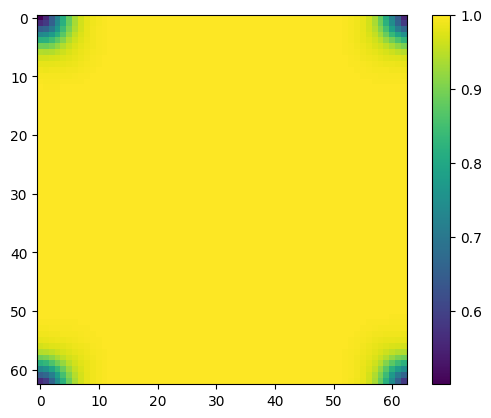

In [36]:
plt.imshow(fourier_precision.abs().squeeze())
plt.colorbar()

# Figure out the low pass frequency cutoff

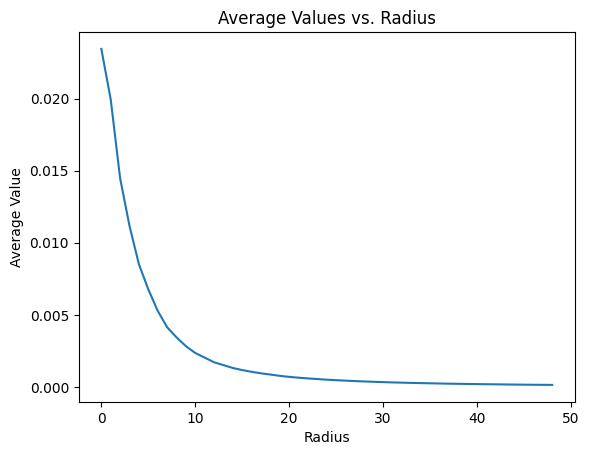

The FWHM occurs at a radius of approximately: 3


In [51]:
def circle_mask(img, r):
    '''Generate a binary mask for a circle of radius r centered in the image.'''
    h, w = img.shape
    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - w/2)**2 + (Y - h/2)**2)
    mask = dist_from_center <= r
    return mask

def compute_averages(img, max_radius):
    '''Compute average of the image values within circles of increasing radii up to max_radius.'''
    averages = []
    for r in range(1, max_radius):
        mask = circle_mask(img, r)
        avg_value = img[mask].mean()
        averages.append(avg_value)
    return averages

averages = compute_averages(kernel.numpy(), kernel_size//2)

# Plotting
plt.plot(averages)
plt.title('Average Values vs. Radius')
plt.xlabel('Radius')
plt.ylabel('Average Value')
plt.show()

# Determining FWHM
half_max = max(averages) / 2
differences = [abs(avg - half_max) for avg in averages]
index_of_FWHM = differences.index(min(differences))

print(f"The FWHM occurs at a radius of approximately: {index_of_FWHM}")

In [58]:
frequencies

array([ 0.        ,  0.00990099,  0.01980198,  0.02970297,  0.03960396,
        0.04950495,  0.05940594,  0.06930693,  0.07920792,  0.08910891,
        0.0990099 ,  0.10891089,  0.11881188,  0.12871287,  0.13861386,
        0.14851485,  0.15841584,  0.16831683,  0.17821782,  0.18811881,
        0.1980198 ,  0.20792079,  0.21782178,  0.22772277,  0.23762376,
        0.24752475,  0.25742574,  0.26732673,  0.27722772,  0.28712871,
        0.2970297 ,  0.30693069,  0.31683168,  0.32673267,  0.33663366,
        0.34653465,  0.35643564,  0.36633663,  0.37623762,  0.38613861,
        0.3960396 ,  0.40594059,  0.41584158,  0.42574257,  0.43564356,
        0.44554455,  0.45544554,  0.46534653,  0.47524752,  0.48514851,
        0.4950495 , -0.4950495 , -0.48514851, -0.47524752, -0.46534653,
       -0.45544554, -0.44554455, -0.43564356, -0.42574257, -0.41584158,
       -0.40594059, -0.3960396 , -0.38613861, -0.37623762, -0.36633663,
       -0.35643564, -0.34653465, -0.33663366, -0.32673267, -0.31

In [67]:
# Constructing fftfreq vector
h, w = kernel.shape
frequencies = np.fft.fftfreq(w)  # Assuming the image is square
nyquist_frequency = frequencies[w//2]

cutoff_frequency = 2 * np.sqrt(2*np.log(2)) / (FWHM * np.sqrt(2 * np.pi**2))

print(f"Cut-off frequency based on FWHM: {cutoff_frequency}")

Cut-off frequency based on FWHM: 0.1766735756795979


In [72]:
np.argmin(abs(frequencies - cutoff_frequency))

18